In [ ]:
import wrds
conn = wrds.Connection()

sp500 = conn.raw_sql("""
    SELECT caldt, spindx
    FROM crsp.dsp500
    WHERE caldt >= '1926-01-01'
    ORDER BY caldt
""")

sp500.to_csv("sp500_crsp.csv", index=False)
print(sp500.shape)
print(sp500.head())

In [39]:
"""
Regime Model - Data Ingestion
===============================
Variables:
    1. Market         - S&P 500 (CRSP csv)
    2. Yield Curve    - US 10yr minus 3-month yield (FRED)
    3. Oil            - WTI Crude (FRED)
    4. Gold           - FRED IQ12260 (testing)
    5. Credit Spread  - BAA minus 10yr (FRED BAA10Y)
    6. Monetary Policy- US 3-month yield (FRED)
    7. Volatility     - VIX (FRED) stitched with realized vol
    8. Stock-Bond Corr- Rolling 3yr correlation S&P500 vs 10yr yield (computed)
"""

import pandas as pd
import numpy as np
from fredapi import Fred

# ── Config ────────────────────────────────────────────────────────────────────
FRED_API_KEY = "db0e8230b3719503f33a50ae27dc9f2a"
START_DATE   = "1926-01-01"
END_DATE     = None

fred = Fred(api_key=FRED_API_KEY)


# ── Helper ────────────────────────────────────────────────────────────────────
def fetch_fred(series_id: str, name: str) -> pd.Series:
    s = fred.get_series(series_id, observation_start=START_DATE)
    s.name = name
    return s.resample("M").last().ffill()


# ── 1. S&P 500 from CRSP ─────────────────────────────────────────────────────
print("Fetching S&P 500...")
sp500_raw           = pd.read_csv("sp500_crsp.csv", parse_dates=["caldt"], index_col="caldt")
sp500_daily         = sp500_raw["spindx"].dropna()
sp500_returns_daily = sp500_daily.pct_change().dropna()
sp500_monthly       = sp500_daily.resample("M").last().rename("sp500")


# ── 2. Yield Curve ────────────────────────────────────────────────────────────
print("Fetching yield curve...")
gs10        = fetch_fred("GS10",  "gs10")
tb3ms       = fetch_fred("TB3MS", "tb3ms")
yield_curve = (gs10 - tb3ms).rename("yield_curve")


# ── 3. Oil ────────────────────────────────────────────────────────────────────
print("Fetching WTI oil...")
oil = fetch_fred("DCOILWTICO", "oil")


# ── 4. Gold & Credit Spread (replacing copper) ───────────────────────────────
print("Fetching gold and credit spread...")
try:
    gold = fetch_fred("IQ12260", "gold")
    print("gold:         ", gold.index[0], gold.shape)
except Exception as e:
    print(f"gold FAILED: {e}")
    gold = None

credit_spread = fetch_fred("BAA10Y", "credit_spread")
print("credit_spread:", credit_spread.index[0], credit_spread.shape)


# ── 5. Monetary Policy ───────────────────────────────────────────────────────
monetary_policy = tb3ms.rename("monetary_policy")


# ── 6. Volatility ────────────────────────────────────────────────────────────
print("Fetching VIX...")
vix          = fetch_fred("VIXCLS", "vix")
realized_vol = (
    sp500_returns_daily
    .rolling(21)
    .std()
    .multiply(np.sqrt(252) * 100)
    .resample("M")
    .last()
    .rename("realized_vol")
)
volatility = vix.combine_first(realized_vol).rename("volatility")


# ── 7. Stock-Bond Correlation ─────────────────────────────────────────────────
print("Computing stock-bond correlation...")
gs10_daily         = fred.get_series("GS10", observation_start=START_DATE)
gs10_returns_daily = gs10_daily.resample("D").last().ffill().pct_change().dropna()

corr_df = pd.DataFrame({
    "sp500": sp500_returns_daily,
    "gs10":  gs10_returns_daily
}).dropna()

stock_bond_corr = (
    corr_df["sp500"]
    .rolling(504)                           # 2yr window (~504 trading days)
    .corr(corr_df["gs10"])
    .resample("M")
    .last()
    .rename("stock_bond_corr")
)


# ── Diagnostics ───────────────────────────────────────────────────────────────
print("\n--- Series diagnostics ---")
print("sp500_monthly:  ", sp500_monthly.shape,   sp500_monthly.index[0])
print("yield_curve:    ", yield_curve.shape,     yield_curve.index[0])
print("oil:            ", oil.shape,             oil.index[0])
if gold is not None:
    print("gold:           ", gold.shape,         gold.index[0])
print("credit_spread:  ", credit_spread.shape,   credit_spread.index[0])
print("monetary_policy:", monetary_policy.shape)
print("volatility:     ", volatility.shape)
print("stock_bond_corr:", stock_bond_corr.shape)


# ── Combine ───────────────────────────────────────────────────────────────────
print("\nCombining all variables...")

series_to_concat = [
    sp500_monthly,
    yield_curve,
    oil,
    credit_spread,
    monetary_policy,
    volatility,
    stock_bond_corr,
]

# only include gold if it loaded successfully
if gold is not None:
    series_to_concat.insert(3, gold)

data = pd.concat(series_to_concat, axis=1)
data.index = pd.to_datetime(data.index)
data = data.loc[START_DATE:].dropna()

print(f"\nFinal dataset shape: {data.shape}")
print(f"Date range: {data.index[0].date()} → {data.index[-1].date()}")
print(f"Columns: {list(data.columns)}")
print(f"\nMissing values:\n{data.isnull().sum()}")
print(f"\nFirst rows:\n{data.head()}")

data.to_csv("regime_raw_data.csv")
print("\nSaved to regime_raw_data.csv")

Fetching S&P 500...
Fetching yield curve...
Fetching WTI oil...
Fetching gold and credit spread...
gold:          1984-12-31 00:00:00 (493,)
credit_spread: 1986-01-31 00:00:00 (482,)
Fetching VIX...
Computing stock-bond correlation...

--- Series diagnostics ---
sp500_monthly:   (750,) 1962-07-31 00:00:00
yield_curve:     (1105,) 1934-01-31 00:00:00
oil:             (482,) 1986-01-31 00:00:00
gold:            (493,) 1984-12-31 00:00:00
credit_spread:   (482,) 1986-01-31 00:00:00
monetary_policy: (1105,)
volatility:      (764,)
stock_bond_corr: (750,)

Combining all variables...

Final dataset shape: (468, 8)
Date range: 1986-01-31 → 2024-12-31
Columns: ['sp500', 'yield_curve', 'oil', 'gold', 'credit_spread', 'monetary_policy', 'volatility', 'stock_bond_corr']

Missing values:
sp500              0
yield_curve        0
oil                0
gold               0
credit_spread      0
monetary_policy    0
volatility         0
stock_bond_corr    0
dtype: int64

First rows:
             sp500 

In [40]:
print(data.shape)
print(data.index[0], data.index[-1])
print(data.describe())

(468, 8)
1986-01-31 00:00:00 2024-12-31 00:00:00
             sp500  yield_curve         oil        gold  credit_spread  \
count   468.000000   468.000000  468.000000  468.000000     468.000000   
mean   1553.713632     1.590577   47.797500   32.541667       2.291517   
std    1267.260026     1.207926   29.723022   22.537700       0.694981   
min     211.780000    -1.570000   10.250000    9.900000       1.300000   
25%     583.682500     0.667500   20.285000   14.100000       1.770000   
50%    1219.610000     1.600000   40.985000   18.100000       2.175000   
75%    2024.522500     2.570000   71.515000   49.025000       2.672500   
max    6032.380000     3.760000  139.960000  102.400000       6.100000   

       monetary_policy  volatility  stock_bond_corr  
count       468.000000  468.000000       468.000000  
mean          3.079808   19.250562         0.028748  
std           2.453290    8.189105         0.070103  
min           0.010000    8.359639        -0.125293  
25%           

Loaded: (468, 8), 1986-01-31 → 2024-12-31
Columns: ['sp500', 'yield_curve', 'oil', 'gold', 'credit_spread', 'monetary_policy', 'volatility', 'stock_bond_corr']

Transformed data: (337, 8)
Date range after transformation: 1996-12-31 → 2024-12-31

Computing Global Scores (this takes ~30 seconds)...
Done.

Computing S&P 500 monthly returns...
Generating regime signal for S&P 500...

Signal distribution:
regime_signal
 1    256
-1     44
 0     37
Name: count, dtype: int64

=== Performance Summary ===
Buy & Hold  Sharpe: 0.55
Timed       Sharpe: 0.48
Buy & Hold  Ann. Return: 8.5%
Timed       Ann. Return: 7.0%


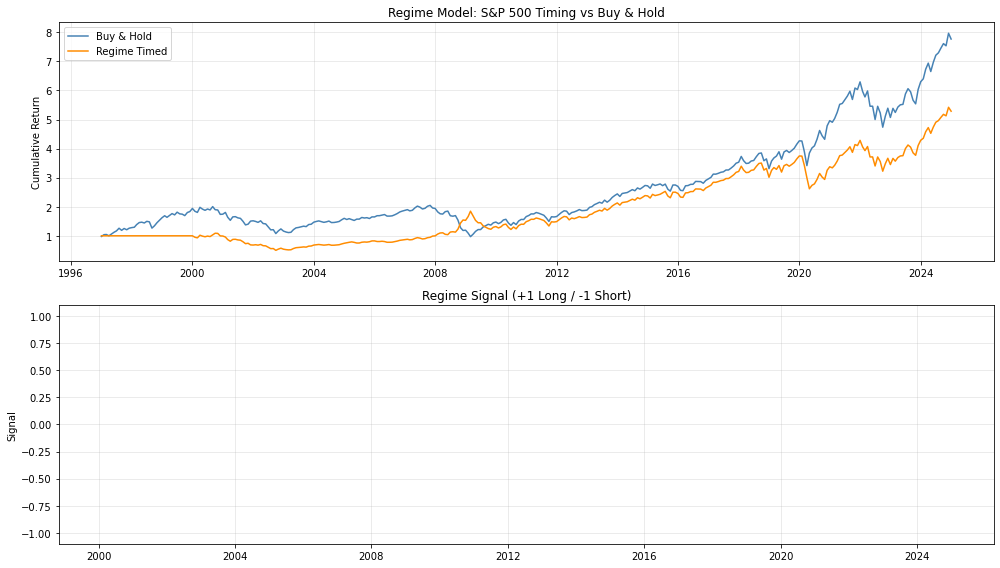

Saved regime_signal.csv and regime_scores.csv


In [44]:
"""
Regime Model - Replication of Man Group Paper
===============================================
Step 1: Transform variables to z-scores (12m change, rolling 10yr, winsorized ±3)
Step 2: Compute Euclidean distance (Global Score) for each historical month
Step 3: Generate similarity-based signal for any target asset
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
data = pd.read_csv("regime_raw_data.csv", index_col=0, parse_dates=True)
print(f"Loaded: {data.shape}, {data.index[0].date()} → {data.index[-1].date()}")
print(f"Columns: {list(data.columns)}\n")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1: Transform variables to z-scores
# Paper: 12-month change, normalized by rolling 10yr std, winsorized at ±3
# ──────────────────────────────────────────────────────────────────────────────

ROLLING_WINDOW = 120   # 10 years of monthly data
WINSOR_LIMIT   = 3.0

def transform_to_zscore(series: pd.Series) -> pd.Series:
    """
    1. Compute 12-month change
    2. Divide by rolling 10yr std of those changes (z-score)
    3. Winsorize at ±3
    """
    change  = series.diff(12)                               # 12-month difference
    std     = change.rolling(ROLLING_WINDOW).std()          # rolling 10yr std
    zscore  = change / std                                  # normalize
    zscore  = zscore.clip(-WINSOR_LIMIT, WINSOR_LIMIT)      # winsorize
    return zscore

transformed = data.apply(transform_to_zscore)
transformed = transformed.dropna()

print(f"Transformed data: {transformed.shape}")
print(f"Date range after transformation: {transformed.index[0].date()} → {transformed.index[-1].date()}\n")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2: Compute Global Score (Euclidean distance)
# For each month T, compute distance to every historical month i
# Exclude last 36 months from similar set (avoid momentum loading)
# ──────────────────────────────────────────────────────────────────────────────

MASK_MONTHS = 36   # exclude most recent 3 years from similarity search

def compute_global_scores(transformed: pd.DataFrame) -> pd.DataFrame:
    """
    For each month T, compute Euclidean distance to all prior months i.
    Returns a DataFrame where scores[T, i] = distance between month T and month i.
    Lower score = more similar.
    """
    values = transformed.values       # shape: (T, n_vars)
    n      = len(transformed)
    scores = np.full((n, n), np.nan)

    for t in range(n):
        # only look at history (no future, exclude last 36 months)
        max_i = max(0, t - MASK_MONTHS)
        if max_i == 0:
            continue
        x_t = values[t]               # today's z-scores
        x_h = values[:max_i]          # historical z-scores

        # Euclidean distance: sqrt of sum of squared differences
        diffs        = x_h - x_t      # shape: (max_i, n_vars)
        sq_distances = np.sum(diffs**2, axis=1)
        distances    = np.sqrt(sq_distances)
        scores[t, :max_i] = distances

    return pd.DataFrame(scores, index=transformed.index, columns=transformed.index)

print("Computing Global Scores (this takes ~30 seconds)...")
scores = compute_global_scores(transformed)
print("Done.\n")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3: Generate similarity signal for a target asset
# - Find the 20% most similar historical months (quintile 1)
# - Look at asset returns in the month AFTER those similar periods
# - Go long if avg return is positive, short if negative
# ──────────────────────────────────────────────────────────────────────────────

SIMILARITY_QUANTILE = 0.20    # top 20% most similar = quintile 1

def compute_regime_signal(scores: pd.DataFrame,
                           asset_returns: pd.Series,
                           quantile: float = SIMILARITY_QUANTILE) -> pd.Series:
    """
    For each month T:
      1. Get similarity scores to all historical months
      2. Select the most similar months (lowest scores, bottom quantile)
      3. Look at asset returns in the month AFTER those similar months
      4. Signal = +1 if avg return > 0, -1 if avg return < 0, 0 if no data
    """
    signals = {}

    for t in scores.index:
        row = scores.loc[t].dropna()
        if len(row) == 0:
            signals[t] = 0
            continue

        # threshold for "similar" = bottom quantile of distances
        threshold    = row.quantile(quantile)
        similar_dates = row[row <= threshold].index

        # get returns in the month AFTER each similar date
        future_returns = []
        for d in similar_dates:
            # find next month in asset_returns after d
            future = asset_returns[asset_returns.index > d]
            if len(future) > 0:
                future_returns.append(future.iloc[0])

        if len(future_returns) == 0:
            signals[t] = 0
        else:
            avg_return = np.mean(future_returns)
            signals[t] = 1 if avg_return > 0 else -1

    return pd.Series(signals, name="regime_signal")


# ── Apply to S&P 500 as a demo ────────────────────────────────────────────────
print("Computing S&P 500 monthly returns...")
sp500_returns = data["sp500"].pct_change().dropna()

# align to transformed index
sp500_returns = sp500_returns.reindex(transformed.index)

print("Generating regime signal for S&P 500...")
signal = compute_regime_signal(scores, sp500_returns)

print(f"\nSignal distribution:\n{signal.value_counts()}\n")


# ── Backtest: timed strategy vs buy & hold ────────────────────────────────────
backtest = pd.DataFrame({
    "returns"      : sp500_returns,
    "signal"       : signal,
}).dropna()

backtest["timed_returns"]   = backtest["signal"] * backtest["returns"]
backtest["cumulative_bh"]   = (1 + backtest["returns"]).cumprod()
backtest["cumulative_timed"]= (1 + backtest["timed_returns"]).cumprod()

# ── Performance metrics ───────────────────────────────────────────────────────
def sharpe(returns, periods=12):
    return (returns.mean() / returns.std()) * np.sqrt(periods)

print("=== Performance Summary ===")
print(f"Buy & Hold  Sharpe: {sharpe(backtest['returns']):.2f}")
print(f"Timed       Sharpe: {sharpe(backtest['timed_returns']):.2f}")
print(f"Buy & Hold  Ann. Return: {backtest['returns'].mean()*12*100:.1f}%")
print(f"Timed       Ann. Return: {backtest['timed_returns'].mean()*12*100:.1f}%")


# ── Plot ──────────────────────────────────────────────────────────────────────
idx = backtest.index.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(idx, backtest["cumulative_bh"].to_numpy(),
             label="Buy & Hold", linewidth=1.5, color="steelblue")
axes[0].plot(idx, backtest["cumulative_timed"].to_numpy(),
             label="Regime Timed", linewidth=1.5, color="darkorange")
axes[0].set_title("Regime Model: S&P 500 Timing vs Buy & Hold")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(idx, backtest["signal"].to_numpy(),
            color=["green" if s > 0 else "red" for s in backtest["signal"]],
            alpha=0.6, width=25)
axes[1].set_title("Regime Signal (+1 Long / -1 Short)")
axes[1].set_ylabel("Signal")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_backtest.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save signal ───────────────────────────────────────────────────────────────
signal.to_csv("regime_signal.csv")
scores.to_csv("regime_scores.csv")
print("Saved regime_signal.csv and regime_scores.csv")

In [45]:
print(backtest[["cumulative_bh", "cumulative_timed"]].tail(10))
print("\n=== Performance Summary ===")
print(f"Buy & Hold  Sharpe: {sharpe(backtest['returns']):.2f}")
print(f"Timed       Sharpe: {sharpe(backtest['timed_returns']):.2f}")
print(f"Buy & Hold  Ann. Return: {backtest['returns'].mean()*12*100:.1f}%")
print(f"Timed       Ann. Return: {backtest['timed_returns'].mean()*12*100:.1f}%")

            cumulative_bh  cumulative_timed
2024-03-31       6.940834          4.722187
2024-04-30       6.651991          4.525673
2024-05-31       6.971427          4.743001
2024-06-30       7.213125          4.907440
2024-07-31       7.294787          4.962999
2024-08-31       7.461362          5.076327
2024-09-30       7.612058          5.178853
2024-10-31       7.536723          5.127599
2024-11-30       7.968587          5.421418
2024-12-31       7.769451          5.285936

=== Performance Summary ===
Buy & Hold  Sharpe: 0.55
Timed       Sharpe: 0.48
Buy & Hold  Ann. Return: 8.5%
Timed       Ann. Return: 7.0%


Scores shape: (337, 337)


IndexError: list index out of range

In [47]:
def download_ff5() -> pd.DataFrame:
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip"
    print("Downloading FF5 factors...")
    with urllib.request.urlopen(url) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
        # print filenames to see what's actually in the zip
        print("Files in zip:", zf.namelist())
        fname = zf.namelist()[0]   # just take the first file
        with zf.open(fname) as f:
            raw = f.read().decode("utf-8").split("\n")

    start = next(i for i, line in enumerate(raw) if line.strip()[:6].isdigit())
    end   = next(i for i, line in enumerate(raw[start:], start)
                 if line.strip() == "" or (line.strip() and not line.strip()[:6].isdigit()))

    df = pd.read_csv(
        io.StringIO("\n".join(raw[start:end])),
        header=None,
        names=["date", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"],
    )
    df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), format="%Y%m")
    df         = df.set_index("date")
    df         = df.apply(pd.to_numeric, errors="coerce") / 100
    df.index   = df.index + pd.offsets.MonthEnd(0)
    return df.dropna()

ff5 = download_ff5()
print(ff5.head())
print(ff5.shape)

Files in zip: ['F-F_Research_Data_5_Factors_2x3.csv']
            Mkt-RF     SMB     HML     RMW     CMA      RF
date                                                      
1963-07-31 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-31  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-30 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-31  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-30 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
(750, 6)


In [48]:
def download_momentum() -> pd.Series:
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip"
    print("Downloading Momentum factor...")
    with urllib.request.urlopen(url) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
        print("Files in zip:", zf.namelist())
        fname = zf.namelist()[0]
        with zf.open(fname) as f:
            raw = f.read().decode("utf-8").split("\n")

    start = next(i for i, line in enumerate(raw) if line.strip()[:6].isdigit())
    end   = next(i for i, line in enumerate(raw[start:], start)
                 if line.strip() == "" or (line.strip() and not line.strip()[:6].isdigit()))

    df = pd.read_csv(
        io.StringIO("\n".join(raw[start:end])),
        header=None,
        names=["date", "Mom"],
    )
    df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), format="%Y%m")
    df         = df.set_index("date")
    df["Mom"]  = pd.to_numeric(df["Mom"], errors="coerce") / 100
    df.index   = df.index + pd.offsets.MonthEnd(0)
    return df["Mom"].dropna()

mom = download_momentum()
print(mom.head())
print(mom.shape)

Files in zip: ['F-F_Momentum_Factor.csv']
date
1927-01-31    0.0057
1927-02-28   -0.0150
1927-03-31    0.0352
1927-04-30    0.0436
1927-05-31    0.0278
Name: Mom, dtype: float64
(1188,)


In [49]:
factors = ff5[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].join(mom, how="inner")
factors.columns = ["Market", "Size", "Value", "Profitability", "Investment", "Momentum"]
print(factors.shape)
print(factors.index[0], factors.index[-1])

(750, 6)
1963-07-31 00:00:00 2025-12-31 00:00:00


Computing quintile signals for all 6 factors...
(This takes a few minutes — 2 quintiles x 6 factors)

  Processing Market...
  Processing Size...
  Processing Value...
  Processing Profitability...
  Processing Investment...
  Processing Momentum...

=== Performance Summary ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
Long-Only Benchmark           0.79       3.6%     -12.4%
Quintile 1 (Similar)          0.51       2.3%     -13.6%
Quintile 5 (Dissimilar)      -0.16      -0.7%     -40.1%
Difference (Q1-Q5)            0.47       3.0%     -20.6%

Corr(Q1, Long-Only):   0.30
Corr(Diff, Long-Only): -0.05


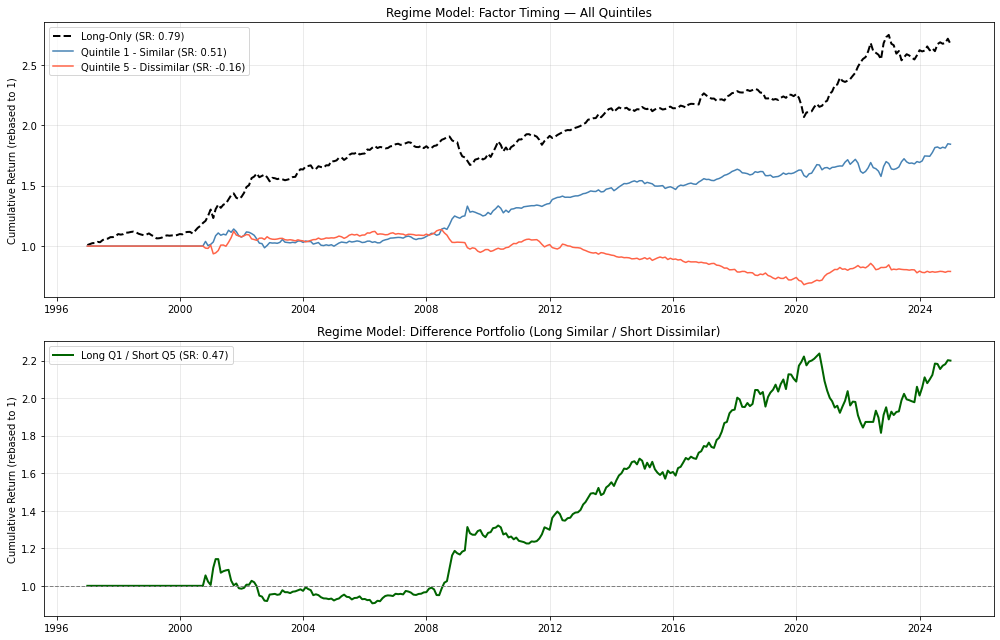


Plot saved to regime_ff_backtest.png


In [51]:
"""
Regime Model - Fama-French Factor Timing + Difference Portfolio
================================================================
Replicates the core result of the Man Group paper:
  - Apply regime signal to 6 FF factors
  - Long quintile 1 (most similar), Short quintile 5 (most dissimilar)
  - Compare difference portfolio vs long-only benchmark
"""

import pandas as pd
import numpy as np
import urllib.request
import zipfile
import io
import matplotlib.pyplot as plt



# ──────────────────────────────────────────────────────────────────────────────
# STEP 2: Generate quintile signals for each factor
# Quintile 1 = 20% most similar, Quintile 5 = 20% most dissimilar
# ──────────────────────────────────────────────────────────────────────────────

def compute_quintile_signal(scores: pd.DataFrame,
                             factor_returns: pd.Series,
                             quintile: int = 1) -> pd.Series:
    """
    For each month T:
      - Get similarity scores to all historical months
      - Quintile 1: bottom 20% distances (most similar)
      - Quintile 5: top 20% distances (most dissimilar)
      - Signal = +1 if avg subsequent return > 0, else -1
    """
    assert quintile in [1, 2, 3, 4, 5], "quintile must be 1-5"

    signals = {}
    q_low  = (quintile - 1) * 0.20
    q_high = quintile       * 0.20

    for t in scores.index:
        row = scores.loc[t].dropna()
        row = row[row > 0]           # remove zeros (self-distance)
        if len(row) < 10:
            signals[t] = 0
            continue

        lo = row.quantile(q_low)  if q_low  > 0 else -np.inf
        hi = row.quantile(q_high)

        selected_dates = row[(row > lo) & (row <= hi)].index

        future_returns = []
        for d in selected_dates:
            future = factor_returns[factor_returns.index > d]
            if len(future) > 0:
                future_returns.append(future.iloc[0])

        if len(future_returns) == 0:
            signals[t] = 0
        else:
            avg = np.mean(future_returns)
            signals[t] = 1 if avg > 0 else -1

    return pd.Series(signals, name=f"q{quintile}_signal")


# align scores to factor date range
common_idx = scores.index.intersection(factors.index)
scores_aligned = scores.loc[common_idx]

print("Computing quintile signals for all 6 factors...")
print("(This takes a few minutes — 2 quintiles x 6 factors)\n")

q1_signals = {}
q5_signals = {}

for factor in factors.columns:
    print(f"  Processing {factor}...")
    f_returns = factors[factor]
    q1_signals[factor] = compute_quintile_signal(scores_aligned, f_returns, quintile=1)
    q5_signals[factor] = compute_quintile_signal(scores_aligned, f_returns, quintile=5)

q1_df = pd.DataFrame(q1_signals)
q5_df = pd.DataFrame(q5_signals)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3: Build portfolios
# Quintile 1 portfolio: equal-weight timed factors using Q1 signal
# Quintile 5 portfolio: equal-weight timed factors using Q5 signal
# Long-only benchmark: always long all 6 factors equally
# Difference portfolio: long Q1, short Q5
# ──────────────────────────────────────────────────────────────────────────────

# align everything
idx = q1_df.index.intersection(factors.index)
q1_df      = q1_df.loc[idx]
q5_df      = q5_df.loc[idx]
factors_aligned = factors.loc[idx]

# timed returns = signal * factor return
q1_returns   = (q1_df * factors_aligned).mean(axis=1)   # equal weight across 6 factors
q5_returns   = (q5_df * factors_aligned).mean(axis=1)
lo_returns   = factors_aligned.mean(axis=1)              # long-only benchmark
diff_returns = q1_returns - q5_returns                   # difference portfolio


# ── Performance metrics ───────────────────────────────────────────────────────
def sharpe(returns, periods=12):
    return (returns.mean() / returns.std()) * np.sqrt(periods)

def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    return dd.min()

def ann_return(returns, periods=12):
    return returns.mean() * periods

print("\n=== Performance Summary ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("Long-Only Benchmark", lo_returns),
                   ("Quintile 1 (Similar)", q1_returns),
                   ("Quintile 5 (Dissimilar)", q5_returns),
                   ("Difference (Q1-Q5)", diff_returns)]:
    print(f"{name:<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# correlation of Q1 and diff with long-only
print(f"\nCorr(Q1, Long-Only):   {q1_returns.corr(lo_returns):.2f}")
print(f"Corr(Diff, Long-Only): {diff_returns.corr(lo_returns):.2f}")


# ── Plot ──────────────────────────────────────────────────────────────────────
cum_lo   = (1 + lo_returns).cumprod()
cum_q1   = (1 + q1_returns).cumprod()
cum_q5   = (1 + q5_returns).cumprod()
cum_diff = (1 + diff_returns).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# left chart equivalent: all quintiles vs long-only
idx_np = cum_lo.index.to_numpy()
axes[0].plot(idx_np, cum_lo.to_numpy(),   label=f"Long-Only (SR: {sharpe(lo_returns):.2f})",
             linewidth=2, color="black", linestyle="--")
axes[0].plot(idx_np, cum_q1.to_numpy(),   label=f"Quintile 1 - Similar (SR: {sharpe(q1_returns):.2f})",
             linewidth=1.5, color="steelblue")
axes[0].plot(idx_np, cum_q5.to_numpy(),   label=f"Quintile 5 - Dissimilar (SR: {sharpe(q5_returns):.2f})",
             linewidth=1.5, color="tomato")
axes[0].set_title("Regime Model: Factor Timing — All Quintiles")
axes[0].set_ylabel("Cumulative Return (rebased to 1)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right chart equivalent: difference portfolio
axes[1].plot(cum_diff.index.to_numpy(), cum_diff.to_numpy(),
             label=f"Long Q1 / Short Q5 (SR: {sharpe(diff_returns):.2f})",
             linewidth=2, color="darkgreen")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Regime Model: Difference Portfolio (Long Similar / Short Dissimilar)")
axes[1].set_ylabel("Cumulative Return (rebased to 1)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_ff_backtest.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to regime_ff_backtest.png")

In [52]:
# ── Load S&P 500 returns for comparison ───────────────────────────────────────
sp500_returns = data["sp500"].pct_change().dropna()
sp500_aligned = sp500_returns.reindex(common_idx).dropna()

# ── Compare all strategies ────────────────────────────────────────────────────
print("=== Full Comparison ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("S&P 500 Buy & Hold",   sp500_aligned),
                   ("FF Long-Only",          lo_returns),
                   ("Difference (Q1-Q5)",    diff_returns),
                   ("Quintile 1 (Similar)",  q1_returns)]:
    print(f"{name:<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# ── What regime are we in RIGHT NOW? ─────────────────────────────────────────
print("\n=== Current Regime Analysis ===")
latest_date = scores.index[-1]
latest_scores = scores.loc[latest_date].dropna()
latest_scores = latest_scores[latest_scores > 0]

# most similar historical periods
n_similar = int(len(latest_scores) * 0.20)
most_similar = latest_scores.nsmallest(n_similar)
most_dissimilar = latest_scores.nlargest(n_similar)

print(f"Current date in model: {latest_date.date()}")
print(f"\nTop 10 most similar historical periods:")
print(most_similar.head(10).index.strftime("%Y-%m").tolist())

print(f"\nTop 10 most dissimilar historical periods:")
print(most_dissimilar.head(10).index.strftime("%Y-%m").tolist())

# current signal for each factor
print("\n=== Current Signal per Factor ===")
for factor in factors.columns:
    sig = q1_df[factor].iloc[-1]
    direction = "LONG" if sig == 1 else "SHORT" if sig == -1 else "NEUTRAL"
    print(f"  {factor:<15}: {direction}")

=== Full Comparison ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
S&P 500 Buy & Hold            0.55       8.5%     -52.6%
FF Long-Only                  0.79       3.6%     -12.4%
Difference (Q1-Q5)            0.47       3.0%     -20.6%
Quintile 1 (Similar)          0.51       2.3%     -13.6%

=== Current Regime Analysis ===
Current date in model: 2024-12-31

Top 10 most similar historical periods:
['2020-11', '2010-05', '2011-07', '2021-01', '2020-12', '2010-06', '2010-07', '2020-08', '2011-02', '2011-03']

Top 10 most dissimilar historical periods:
['2008-12', '2009-02', '2009-01', '2008-11', '2001-03', '2008-10', '2009-03', '2001-09', '2009-04', '2000-12']

=== Current Signal per Factor ===
  Market         : LONG
  Size           : LONG
  Value          : SHORT
  Profitability  : LONG
  Investment     : SHORT
  Momentum       : LONG


=== Factor Portfolio: Regime Tilt vs Benchmarks ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Equal Weight Factors               0.79       3.6%     -12.4%
Regime Tilted Factors              0.76       3.9%     -13.4%

Corr(Tilt, Equal Weight): 0.87
Corr(Tilt, S&P 500):      0.29

=== Current Portfolio Weights (based on latest signal) ===
  Market         :  22.7%  (LONG ↑)
  Size           :  22.7%  (LONG ↑)
  Value          :   4.5%  (SHORT ↓)
  Profitability  :  22.7%  (LONG ↑)
  Investment     :   4.5%  (SHORT ↓)
  Momentum       :  22.7%  (LONG ↑)


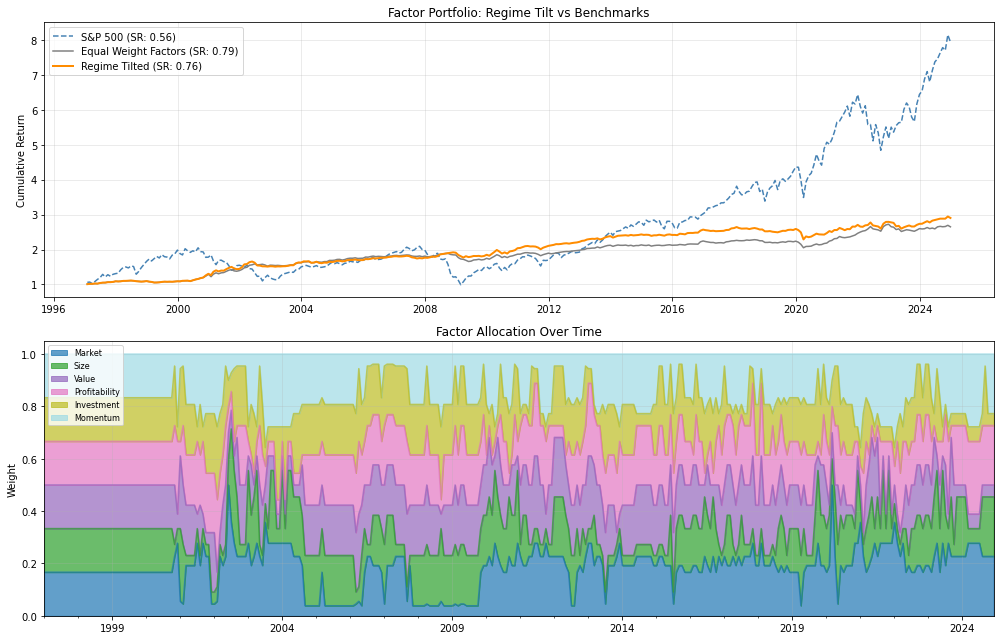

In [54]:
# ── Factor ETF Portfolio with Regime Tilts ────────────────────────────────────
# Base: equal weight across 6 factors
# Tilt: overweight LONG signals, underweight SHORT signals

BASE_WEIGHT  = 1/6        # 16.7% each
LONG_WEIGHT  = 0.25       # overweight to 25%
SHORT_WEIGHT = 0.05       # underweight to 5%

def compute_factor_weights(signals_row: pd.Series) -> pd.Series:
    """Convert signals (+1/-1/0) to portfolio weights that sum to 1."""
    weights = {}
    for factor, sig in signals_row.items():
        if sig == 1:
            weights[factor] = LONG_WEIGHT
        elif sig == -1:
            weights[factor] = SHORT_WEIGHT
        else:
            weights[factor] = BASE_WEIGHT
    # normalize to sum to 1
    total = sum(weights.values())
    return pd.Series({k: v/total for k, v in weights.items()})

# compute weights for each month using Q1 signals
weights_df = q1_df.apply(compute_factor_weights, axis=1)

# align factors and weights
strat_idx      = weights_df.index.intersection(factors.index)
weights_aligned = weights_df.reindex(strat_idx).shift(1).dropna()  # shift 1 to avoid lookahead
factors_aligned = factors.reindex(weights_aligned.index)
sp500_aligned   = sp500_returns.reindex(weights_aligned.index).dropna()

# portfolio return = sum of (weight * factor return) each month
tilt_returns   = (weights_aligned * factors_aligned).sum(axis=1)
equal_returns  = factors_aligned.mean(axis=1)            # equal weight benchmark
sp500_ret_plot = sp500_aligned.reindex(tilt_returns.index)

# ── Performance ───────────────────────────────────────────────────────────────
print("=== Factor Portfolio: Regime Tilt vs Benchmarks ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",        sp500_ret_plot),
                   ("Equal Weight Factors",      equal_returns),
                   ("Regime Tilted Factors",     tilt_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nCorr(Tilt, Equal Weight): {tilt_returns.corr(equal_returns):.2f}")
print(f"Corr(Tilt, S&P 500):      {tilt_returns.corr(sp500_ret_plot):.2f}")

# ── Current weights ───────────────────────────────────────────────────────────
print("\n=== Current Portfolio Weights (based on latest signal) ===")
current_weights = weights_df.iloc[-1]
for factor, w in current_weights.items():
    signal_str = "LONG ↑" if q1_df[factor].iloc[-1] == 1 else "SHORT ↓" if q1_df[factor].iloc[-1] == -1 else "NEUTRAL"
    print(f"  {factor:<15}: {w*100:>5.1f}%  ({signal_str})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

cum_sp  = (1 + sp500_ret_plot).cumprod()
cum_eq  = (1 + equal_returns).cumprod()
cum_tlt = (1 + tilt_returns).cumprod()
idx_np  = cum_tlt.index.to_numpy()

axes[0].plot(idx_np, cum_sp.to_numpy(),  label=f"S&P 500 (SR: {sharpe(sp500_ret_plot):.2f})",
             color="steelblue",  linewidth=1.5, linestyle="--")
axes[0].plot(idx_np, cum_eq.to_numpy(),  label=f"Equal Weight Factors (SR: {sharpe(equal_returns):.2f})",
             color="gray",       linewidth=1.5)
axes[0].plot(idx_np, cum_tlt.to_numpy(), label=f"Regime Tilted (SR: {sharpe(tilt_returns):.2f})",
             color="darkorange", linewidth=2)
axes[0].set_title("Factor Portfolio: Regime Tilt vs Benchmarks")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# weights over time
weights_aligned.plot.area(ax=axes[1], stacked=True, alpha=0.7,
                           colormap="tab20")
axes[1].set_title("Factor Allocation Over Time")
axes[1].set_ylabel("Weight")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_factor_portfolio.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# ── Long-only top factors, avoid bottom factors ───────────────────────────────
# Each month: only hold factors with LONG signal
# If all signals are flat, hold equal weight
# Compare against S&P 500

def compute_longonly_weights(signals_row: pd.Series) -> pd.Series:
    long_factors = [f for f, s in signals_row.items() if s == 1]
    if len(long_factors) == 0:
        # fallback to equal weight if no longs
        return pd.Series({f: 1/len(signals_row) for f in signals_row.index})
    weight = 1 / len(long_factors)
    return pd.Series({f: weight if f in long_factors else 0.0
                      for f in signals_row.index})

weights_lo    = q1_df.apply(compute_longonly_weights, axis=1)
weights_lo_al = weights_lo.reindex(strat_idx).shift(1).dropna()
factors_lo    = factors.reindex(weights_lo_al.index)
sp500_lo      = sp500_returns.reindex(weights_lo_al.index)

longonly_tilt = (weights_lo_al * factors_lo).sum(axis=1)

print("=== Long Best Factors Only vs S&P 500 ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",     sp500_lo),
                   ("Equal Weight Factors",   factors_lo.mean(axis=1)),
                   ("Long Best Factors Only", longonly_tilt)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# how many factors are held each month on average
avg_factors_held = (weights_lo_al > 0).sum(axis=1).mean()
print(f"\nAvg factors held per month: {avg_factors_held:.1f}")
print(f"Corr(Strategy, S&P 500): {longonly_tilt.corr(sp500_lo):.2f}")

=== Long Best Factors Only vs S&P 500 ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Equal Weight Factors               0.79       3.6%     -12.4%
Long Best Factors Only             0.60       3.7%     -18.6%

Avg factors held per month: 4.6
Corr(Strategy, S&P 500): 0.32


In [56]:
# ── Long/Short S&P 500 using regime signal ────────────────────────────────────
# Q1 signal on S&P 500 = LONG
# Q5 signal on S&P 500 = SHORT  
# Neither = cash (0)

# recompute Q1 and Q5 signals specifically for S&P 500
print("Computing Q1 and Q5 signals for S&P 500...")
sp500_q1 = compute_quintile_signal(scores_aligned, sp500_returns, quintile=1)
sp500_q5 = compute_quintile_signal(scores_aligned, sp500_returns, quintile=5)

# combined signal: +1 if Q1=long, -1 if Q5=short, 0 if neither or conflicting
combined_signal = pd.Series(0, index=sp500_q1.index)
combined_signal[sp500_q1 == 1]  =  1
combined_signal[sp500_q5 == -1] = -1

# align
sig_idx      = combined_signal.index.intersection(sp500_returns.index)
sig_aligned  = combined_signal.reindex(sig_idx).shift(1).dropna()
sp500_sig    = sp500_returns.reindex(sig_aligned.index)

ls_returns   = sig_aligned * sp500_sig

print("=== Long/Short S&P 500 vs Buy & Hold ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",    sp500_sig),
                   ("L/S S&P 500",           ls_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nSignal distribution:")
print(sig_aligned.value_counts())
print(f"\nCorr(L/S, S&P 500): {ls_returns.corr(sp500_sig):.2f}")

Computing Q1 and Q5 signals for S&P 500...
=== Long/Short S&P 500 vs Buy & Hold ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
L/S S&P 500                       -0.05      -0.7%     -63.1%

Signal distribution:
 1.0    126
-1.0    124
 0.0     86
Name: count, dtype: int64

Corr(L/S, S&P 500): 0.16


In [57]:
# Long when similar (Q1=long), Cash when dissimilar (Q5=short)
# No shorting — just sidestep bad regimes

cash_signal = sp500_q1.reindex(sig_idx).shift(1).dropna()
# 1 = long SP500, 0 = cash (Q5 or neutral)
cash_signal_binary = (cash_signal == 1).astype(int)

cash_returns = cash_signal_binary * sp500_sig

print("=== Market Timing vs Buy & Hold ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",  sp500_sig),
                   ("Regime Market Timing", cash_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nMonths invested: {cash_signal_binary.sum()} / {len(cash_signal_binary)}")

=== Market Timing vs Buy & Hold ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Regime Market Timing               0.54       6.8%     -37.5%

Months invested: 247 / 336


In [58]:
# When similar (Q1=long)  → long S&P 500
# When dissimilar or neutral → rotate to bonds
# Use realized bond returns approximated from 10yr yield

bond_ret = bond_ret_approx.reindex(sig_aligned.index)

# 1 = in equities, 0 = in bonds
in_equity = (cash_signal_binary == 1)

rotation_returns = pd.Series(index=sig_aligned.index, dtype=float)
rotation_returns[in_equity]  = sp500_sig[in_equity]
rotation_returns[~in_equity] = bond_ret[~in_equity]

print("=== Equity/Bond Rotation vs Benchmarks ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",      sp500_sig),
                   ("Cash Timing",             cash_returns),
                   ("Equity/Bond Rotation",    rotation_returns)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

print(f"\nMonths in equity: {in_equity.sum()} / {len(in_equity)}")
print(f"Months in bonds:  {(~in_equity).sum()} / {len(in_equity)}")

=== Equity/Bond Rotation vs Benchmarks ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6%     -52.6%
Cash Timing                        0.54       6.8%     -37.5%
Equity/Bond Rotation               0.51       6.6%     -42.5%

Months in equity: 247 / 336
Months in bonds:  89 / 336


In [59]:
def download_ff_industries() -> pd.DataFrame:
    """Download FF 12 Industry Portfolios from Ken French."""
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/12_Industry_Portfolios_CSV.zip"
    print("Downloading FF 12 Industry Portfolios...")
    with urllib.request.urlopen(url) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
        print("Files in zip:", zf.namelist())
        fname = zf.namelist()[0]
        with zf.open(fname) as f:
            raw = f.read().decode("utf-8").split("\n")

    # find data start
    start = next(i for i, line in enumerate(raw)
                 if line.strip()[:6].isdigit())
    # find end (blank line or annual section)
    end = next(i for i, line in enumerate(raw[start:], start)
               if line.strip() == "" or
               (line.strip() and not line.strip()[:6].isdigit()))

    df = pd.read_csv(io.StringIO("\n".join(raw[start:end])), header=None)
    df.columns = ["date"] + list(df.columns[1:])
    df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), format="%Y%m")
    df = df.set_index("date")
    df = df.apply(pd.to_numeric, errors="coerce") / 100
    df.index = df.index + pd.offsets.MonthEnd(0)

    # name the 12 industries
    df.columns = ["NoDur", "Durbl", "Manuf", "Enrgy",
                  "HiTec", "Telcm", "Shops", "Hlth",
                  "Utils", "Other", "Finance", "Other2"]
    return df.dropna()

industries = download_ff_industries()
print(f"\nIndustries shape: {industries.shape}")
print(f"Date range: {industries.index[0].date()} → {industries.index[-1].date()}")
print(f"\nColumns: {list(industries.columns)}")
print(f"\nSample:\n{industries.head()}")

Files in zip: ['12_Industry_Portfolios.csv']

Industries shape: (1194, 12)
Date range: 1926-07-31 → 2025-12-31

Columns: ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other', 'Finance', 'Other2']

Sample:
             NoDur   Durbl   Manuf   Enrgy   HiTec   Telcm   Shops    Hlth  \
date                                                                         
1926-07-31  0.0144  0.1390  0.0367 -0.0114  0.0802  0.0315  0.0083  0.0704   
1926-08-31  0.0399  0.0370  0.0241  0.0343  0.0510  0.0198  0.0217 -0.0170   
1926-09-30  0.0115  0.0498 -0.0007 -0.0330  0.0538 -0.0035  0.0242  0.0205   
1926-10-31 -0.0124 -0.0839 -0.0318 -0.0078 -0.0455 -0.0538 -0.0011 -0.0327   
1926-11-30  0.0521 -0.0017  0.0403  0.0001  0.0509  0.0479  0.0163  0.0440   

             Utils   Other  Finance  Other2  
date                                         
1926-07-31  0.0012  0.0185  -0.0002  0.0223  
1926-08-31 -0.0072  0.0417   0.0426  0.0435  
1926-09-30  0.0021  0.0069  

Computing expected returns for all 12 sectors...
(Takes a few minutes...)

  NoDur...
  Durbl...
  Manuf...
  Enrgy...
  HiTec...
  Telcm...
  Shops...
  Hlth...
  Utils...
  Other...
  Finance...
  Other2...

Done.

=== Sector Rotation vs Benchmarks ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 Buy & Hold                 0.56       8.6% -52.6%
Equal Weight Sectors               0.70      10.8% -49.5%
Regime Sector Rotation             0.71      11.7% -44.9%

Corr(Rotation, S&P 500):      0.93
Corr(Rotation, Equal Sectors):0.95

=== Sector Selection Frequency ===
  Enrgy       : 71.1% of months
  Manuf       : 69.3% of months
  Hlth        : 59.5% of months
  Telcm       : 50.6% of months
  Finance     : 48.2% of months
  Other       : 45.8% of months
  HiTec       : 38.7% of months
  NoDur       : 32.1% of months
  Durbl       : 28.3% of months
  Shops       : 26.2% of months
  Utils       : 20.8%

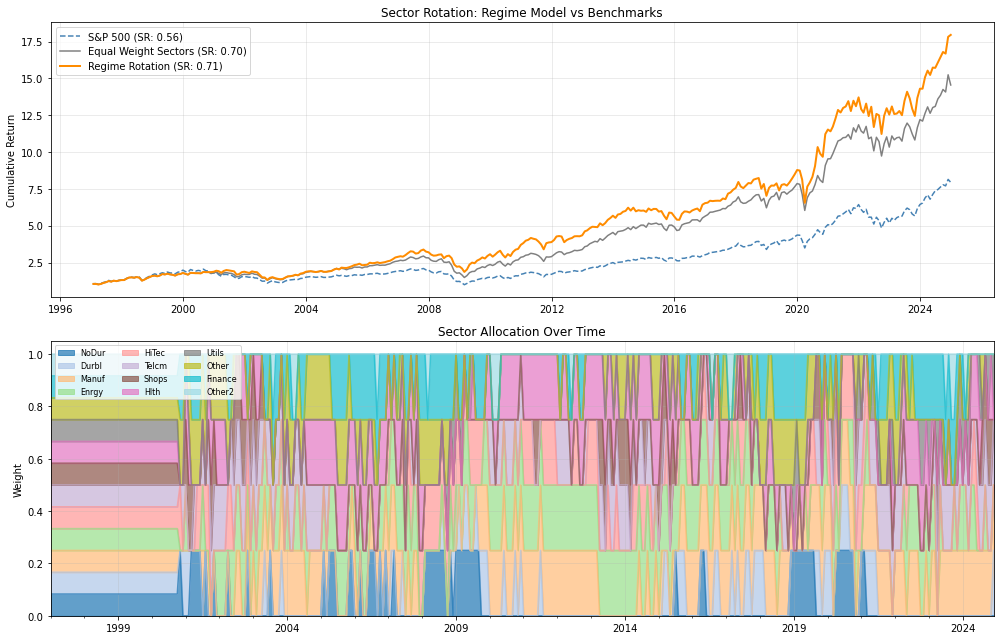

In [60]:
# ── Sector Rotation using Regime Signal ───────────────────────────────────────
# Each month: rank sectors by avg return after similar historical periods
# Hold top N sectors equally weighted
# Compare vs S&P 500 and equal weight sectors

TOP_N = 4   # hold top 4 sectors each month

def compute_sector_signal(scores: pd.DataFrame,
                           sector_returns: pd.Series) -> pd.Series:
    """
    For each month T, compute expected return for a sector
    based on average return after similar historical periods.
    Returns expected return (not just direction) so we can rank sectors.
    """
    expected_returns = {}

    for t in scores.index:
        row = scores.loc[t].dropna()
        row = row[row > 0]
        if len(row) < 10:
            expected_returns[t] = np.nan
            continue

        # top 20% most similar
        threshold     = row.quantile(0.20)
        similar_dates = row[row <= threshold].index

        future_rets = []
        for d in similar_dates:
            future = sector_returns[sector_returns.index > d]
            if len(future) > 0:
                future_rets.append(future.iloc[0])

        expected_returns[t] = np.mean(future_rets) if future_rets else np.nan

    return pd.Series(expected_returns, name=sector_returns.name)


# align scores to industry date range
common_idx      = scores.index.intersection(industries.index)
scores_sect     = scores.loc[common_idx]
industries_al   = industries.reindex(common_idx)
sp500_sect      = sp500_returns.reindex(common_idx)

print("Computing expected returns for all 12 sectors...")
print("(Takes a few minutes...)\n")

sector_expected = {}
for sector in industries.columns:
    print(f"  {sector}...")
    sector_expected[sector] = compute_sector_signal(
        scores_sect, industries[sector]
    )

expected_df = pd.DataFrame(sector_expected)
print("\nDone.")


# ── Build rotation portfolio ──────────────────────────────────────────────────
# Each month: rank sectors by expected return, hold top N equally weighted

def build_rotation_weights(expected_row: pd.Series, top_n: int) -> pd.Series:
    valid = expected_row.dropna()
    if len(valid) == 0:
        return pd.Series(1/len(expected_row), index=expected_row.index)
    top_sectors = valid.nlargest(top_n).index
    weights = pd.Series(0.0, index=expected_row.index)
    weights[top_sectors] = 1.0 / top_n
    return weights

rotation_weights = expected_df.apply(
    lambda row: build_rotation_weights(row, TOP_N), axis=1
)

# shift 1 month to avoid lookahead
rotation_weights_shifted = rotation_weights.shift(1).dropna()
industries_rot  = industries_al.reindex(rotation_weights_shifted.index)
sp500_rot       = sp500_sect.reindex(rotation_weights_shifted.index)

rotation_ret    = (rotation_weights_shifted * industries_rot).sum(axis=1)
equal_sect_ret  = industries_rot.mean(axis=1)

# ── Performance ───────────────────────────────────────────────────────────────
print("\n=== Sector Rotation vs Benchmarks ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 Buy & Hold",     sp500_rot),
                   ("Equal Weight Sectors",   equal_sect_ret),
                   ("Regime Sector Rotation", rotation_ret)]:
    print(f"{name:<30} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:.1f}%")

print(f"\nCorr(Rotation, S&P 500):      {rotation_ret.corr(sp500_rot):.2f}")
print(f"Corr(Rotation, Equal Sectors):{rotation_ret.corr(equal_sect_ret):.2f}")

# ── Which sectors are selected most often ─────────────────────────────────────
print("\n=== Sector Selection Frequency ===")
selection_freq = (rotation_weights_shifted > 0).mean().sort_values(ascending=False)
for sector, freq in selection_freq.items():
    print(f"  {sector:<12}: {freq*100:.1f}% of months")

# ── Current sector allocation ──────────────────────────────────────────────────
print("\n=== Current Sector Allocation ===")
current = rotation_weights.iloc[-1].sort_values(ascending=False)
for sector, w in current.items():
    if w > 0:
        exp_ret = expected_df[sector].iloc[-1]
        print(f"  {sector:<12}: {w*100:.0f}%  (expected regime return: {exp_ret*100:.2f}%)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

cum_sp   = (1 + sp500_rot).cumprod()
cum_eq   = (1 + equal_sect_ret).cumprod()
cum_rot  = (1 + rotation_ret).cumprod()
idx_np   = cum_rot.index.to_numpy()

axes[0].plot(idx_np, cum_sp.to_numpy(),
             label=f"S&P 500 (SR: {sharpe(sp500_rot):.2f})",
             color="steelblue", linewidth=1.5, linestyle="--")
axes[0].plot(idx_np, cum_eq.to_numpy(),
             label=f"Equal Weight Sectors (SR: {sharpe(equal_sect_ret):.2f})",
             color="gray", linewidth=1.5)
axes[0].plot(idx_np, cum_rot.to_numpy(),
             label=f"Regime Rotation (SR: {sharpe(rotation_ret):.2f})",
             color="darkorange", linewidth=2)
axes[0].set_title("Sector Rotation: Regime Model vs Benchmarks")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# sector weights over time
rotation_weights_shifted.plot.area(
    ax=axes[1], stacked=True, alpha=0.7, colormap="tab20"
)
axes[1].set_title("Sector Allocation Over Time")
axes[1].set_ylabel("Weight")
axes[1].legend(loc="upper left", fontsize=8, ncol=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regime_sector_rotation.png", dpi=150, bbox_inches="tight")
plt.show()

In [63]:
for top_n in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    w = expected_df.apply(lambda row: build_rotation_weights(row, top_n), axis=1)
    w_shifted = w.shift(1).dropna()
    ret = (w_shifted * industries_al.reindex(w_shifted.index)).sum(axis=1)
    print(f"Top {top_n}: Sharpe={sharpe(ret):.2f}  AnnRet={ann_return(ret)*100:.1f}%  MaxDD={max_drawdown(ret)*100:.1f}%")

Top 2: Sharpe=0.67  AnnRet=12.1%  MaxDD=-45.6%
Top 3: Sharpe=0.73  AnnRet=12.3%  MaxDD=-45.8%
Top 4: Sharpe=0.71  AnnRet=11.7%  MaxDD=-44.9%
Top 5: Sharpe=0.78  AnnRet=12.4%  MaxDD=-44.7%
Top 6: Sharpe=0.77  AnnRet=12.1%  MaxDD=-47.7%
Top 7: Sharpe=0.76  AnnRet=11.7%  MaxDD=-49.1%
Top 8: Sharpe=0.74  AnnRet=11.5%  MaxDD=-48.7%
Top 9: Sharpe=0.74  AnnRet=11.3%  MaxDD=-50.8%
Top 10: Sharpe=0.72  AnnRet=11.1%  MaxDD=-50.9%
Top 11: Sharpe=0.70  AnnRet=10.7%  MaxDD=-50.1%
Top 12: Sharpe=0.70  AnnRet=10.8%  MaxDD=-49.5%


In [64]:
def build_longshort_weights(expected_row, top_n=4, bottom_n=2):
    valid = expected_row.dropna()
    if len(valid) == 0:
        return pd.Series(0.0, index=expected_row.index)
    weights = pd.Series(0.0, index=expected_row.index)
    weights[valid.nlargest(top_n).index]  =  1.0 / top_n
    weights[valid.nsmallest(bottom_n).index] = -1.0 / bottom_n
    return weights

In [65]:
for top_n in [2, 3, 4, 5, 6]:
    w = expected_df.apply(
        lambda row: build_rotation_weights(row, top_n), axis=1
    )
    w_shifted = w.shift(1).dropna()
    ind_ret   = industries_al.reindex(w_shifted.index)
    ret       = (w_shifted * ind_ret).sum(axis=1)
    print(f"Top {top_n}: Sharpe={sharpe(ret):.2f}  "
          f"AnnRet={ann_return(ret)*100:.1f}%  "
          f"MaxDD={max_drawdown(ret)*100:.1f}%")

Top 2: Sharpe=0.67  AnnRet=12.1%  MaxDD=-45.6%
Top 3: Sharpe=0.73  AnnRet=12.3%  MaxDD=-45.8%
Top 4: Sharpe=0.71  AnnRet=11.7%  MaxDD=-44.9%
Top 5: Sharpe=0.78  AnnRet=12.4%  MaxDD=-44.7%
Top 6: Sharpe=0.77  AnnRet=12.1%  MaxDD=-47.7%


In [69]:
# ── Weight functions ──────────────────────────────────────────────────────────
def long_only_weights(expected_row, top_n):
    valid = expected_row.dropna()
    if len(valid) == 0:
        return pd.Series(1/len(expected_row), index=expected_row.index)
    weights = pd.Series(0.0, index=expected_row.index)
    weights[valid.nlargest(top_n).index] = 1.0 / top_n
    return weights

def long_short_weights(expected_row, top_n, bottom_n):
    valid = expected_row.dropna()
    if len(valid) < top_n + bottom_n:
        return pd.Series(0.0, index=expected_row.index)
    weights = pd.Series(0.0, index=expected_row.index)
    weights[valid.nlargest(top_n).index]    =  1.0 / top_n
    weights[valid.nsmallest(bottom_n).index] = -1.0 / bottom_n
    return weights

# ── Grid search ───────────────────────────────────────────────────────────────
results = []

sp500_b = sp500_returns.reindex(industries_al.index).dropna()
equal_b = industries_al.reindex(sp500_b.index).mean(axis=1)
results.append({"Strategy": "S&P 500 B&H",  "Sharpe": sharpe(sp500_b),  "Ann Ret": ann_return(sp500_b)*100,  "Max DD": max_drawdown(sp500_b)*100})
results.append({"Strategy": "Equal Sectors", "Sharpe": sharpe(equal_b),  "Ann Ret": ann_return(equal_b)*100,  "Max DD": max_drawdown(equal_b)*100})

for top_n in [2, 3, 4,5,6,8,12]:
    w   = expected_df.apply(lambda r, n=top_n: long_only_weights(r, n), axis=1)
    ret = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    results.append({"Strategy": f"LongOnly Top{top_n}", "Sharpe": sharpe(ret), "Ann Ret": ann_return(ret)*100, "Max DD": max_drawdown(ret)*100})

for top_n, bot_n in [(3,3),(4,4), (5,5), (6,6)]:
    w   = expected_df.apply(lambda r, n=top_n, b=bot_n: long_short_weights(r, n, b), axis=1)
    ret = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    results.append({"Strategy": f"L/S Top{top_n}/Bot{bot_n}", "Sharpe": sharpe(ret), "Ann Ret": ann_return(ret)*100, "Max DD": max_drawdown(ret)*100})

print(f"{'Strategy':<22} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 52)
for r in results:
    print(f"{r['Strategy']:<22} {r['Sharpe']:>8.2f} {r['Ann Ret']:>9.1f}% {r['Max DD']:>9.1f}%")

Strategy                 Sharpe    Ann Ret     Max DD
----------------------------------------------------
S&P 500 B&H                0.55       8.5%     -52.6%
Equal Sectors              0.70      10.7%     -49.5%
LongOnly Top2              0.67      12.1%     -45.6%
LongOnly Top3              0.73      12.3%     -45.8%
LongOnly Top4              0.71      11.7%     -44.9%
LongOnly Top5              0.78      12.4%     -44.7%
LongOnly Top6              0.77      12.1%     -47.7%
LongOnly Top8              0.74      11.5%     -48.7%
LongOnly Top12             0.70      10.8%     -49.5%
L/S Top3/Bot3              0.29       3.2%     -33.2%
L/S Top4/Bot4              0.27       2.3%     -29.7%
L/S Top5/Bot5              0.41       3.0%     -19.9%
L/S Top6/Bot6              0.39       2.6%     -20.9%


In [70]:
# ── True alpha: Top5 vs Equal Weight (proper baseline) ───────────────────────

# equal weight - recompute cleanly
eq_idx    = industries_al.index
equal_ret = industries_al.mean(axis=1)

# top 5 long only
w_top5   = expected_df.apply(lambda r: long_only_weights(r, 5), axis=1)
w_shifted = w_top5.shift(1).dropna()
top5_ret  = (w_shifted * industries_al.reindex(w_shifted.index)).sum(axis=1)

# align
idx = top5_ret.index.intersection(equal_ret.index).intersection(sp500_b.index)

print("=== True Outperformance vs Proper Baselines ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
for name, ret in [("S&P 500 B&H",        sp500_b.reindex(idx)),
                   ("Equal Weight (baseline)", equal_ret.reindex(idx)),
                   ("Regime Top 5",       top5_ret.reindex(idx))]:
    print(f"{name:<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

# the real question
alpha = ann_return(top5_ret.reindex(idx)) - ann_return(equal_ret.reindex(idx))
print(f"\nTrue alpha over equal weight: {alpha*100:.1f}% per year")
print(f"Sharpe improvement: {sharpe(top5_ret.reindex(idx)) - sharpe(equal_ret.reindex(idx)):.2f}")

=== True Outperformance vs Proper Baselines ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
S&P 500 B&H                   0.56       8.6%     -52.6%
Equal Weight (baseline)       0.70      10.8%     -49.5%
Regime Top 5                  0.78      12.4%     -44.7%

True alpha over equal weight: 1.6% per year
Sharpe improvement: 0.08


In [71]:
# ── Optimization grid ─────────────────────────────────────────────────────────
from itertools import product

def compute_expected_fwd(scores, industries, quantile=0.20, fwd_months=1):
    """Expected returns looking fwd_months ahead instead of just 1."""
    expected = {}
    for sector in industries.columns:
        sect_ret = industries[sector]
        exp_ret  = {}
        for t in scores.index:
            row = scores.loc[t].dropna()
            row = row[row > 0]
            if len(row) < 10:
                exp_ret[t] = np.nan
                continue
            threshold     = row.quantile(quantile)
            similar_dates = row[row <= threshold].index
            future_rets   = []
            for d in similar_dates:
                # average return over next fwd_months
                future = sect_ret[sect_ret.index > d].iloc[:fwd_months]
                if len(future) > 0:
                    future_rets.append(future.mean())
            exp_ret[t] = np.mean(future_rets) if future_rets else np.nan
        expected[sector] = pd.Series(exp_ret)
    return pd.DataFrame(expected)


def add_momentum_filter(expected_df, industries, mom_window=3):
    """
    Blend regime signal with momentum.
    Final score = 0.5 * regime_score_rank + 0.5 * momentum_rank
    """
    # momentum = trailing mom_window month return
    momentum = industries.rolling(mom_window).mean()
    
    # rank both signals cross-sectionally each month (0-1)
    regime_rank = expected_df.rank(axis=1, pct=True)
    mom_rank    = momentum.reindex(expected_df.index).rank(axis=1, pct=True)
    
    # blend
    combined = 0.5 * regime_rank + 0.5 * mom_rank
    return combined


results_opt = []

# add baseline
equal_ret = industries_al.mean(axis=1)
results_opt.append({
    "Config": "Equal Weight baseline",
    "Quantile": "-", "Fwd": "-", "Momentum": "No", "Top N": "-",
    "Sharpe": round(sharpe(equal_ret), 2),
    "Ann Ret": round(ann_return(equal_ret)*100, 1),
    "Max DD": round(max_drawdown(equal_ret)*100, 1)
})

for q, fwd, use_mom, top_n in product(
    [0.10, 0.15, 0.20],   # quantiles
    [1, 3],                # forward months
    [False, True],         # momentum filter
    [3, 5]                 # top n sectors
):
    print(f"Testing q={q}, fwd={fwd}, mom={use_mom}, top={top_n}...")
    
    exp = compute_expected_fwd(scores_sect, industries, quantile=q, fwd_months=fwd)
    exp_al = exp.reindex(industries_al.index)
    
    if use_mom:
        signal = add_momentum_filter(exp_al, industries_al, mom_window=3)
    else:
        signal = exp_al
    
    w   = signal.apply(lambda r: long_only_weights(r, top_n), axis=1)
    ret = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    
    results_opt.append({
        "Config"  : f"q={q} fwd={fwd} mom={use_mom} top{top_n}",
        "Quantile": q,
        "Fwd"     : fwd,
        "Momentum": use_mom,
        "Top N"   : top_n,
        "Sharpe"  : round(sharpe(ret), 2),
        "Ann Ret" : round(ann_return(ret)*100, 1),
        "Max DD"  : round(max_drawdown(ret)*100, 1)
    })

res_df = pd.DataFrame(results_opt)

print("\n=== Top 15 Configurations by Sharpe ===")
print(f"{'Config':<35} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 65)
for _, row in res_df.sort_values("Sharpe", ascending=False).head(15).iterrows():
    print(f"{row['Config']:<35} {row['Sharpe']:>8.2f} {row['Ann Ret']:>9.1f}% {row['Max DD']:>9.1f}%")

print("\n=== Top 15 Configurations by Ann Return ===")
print(f"{'Config':<35} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 65)
for _, row in res_df.sort_values("Ann Ret", ascending=False).head(15).iterrows():
    print(f"{row['Config']:<35} {row['Sharpe']:>8.2f} {row['Ann Ret']:>9.1f}% {row['Max DD']:>9.1f}%")

res_df.to_csv("regime_optimization.csv", index=False)

Testing q=0.1, fwd=1, mom=False, top=3...
Testing q=0.1, fwd=1, mom=False, top=5...
Testing q=0.1, fwd=1, mom=True, top=3...
Testing q=0.1, fwd=1, mom=True, top=5...
Testing q=0.1, fwd=3, mom=False, top=3...
Testing q=0.1, fwd=3, mom=False, top=5...
Testing q=0.1, fwd=3, mom=True, top=3...
Testing q=0.1, fwd=3, mom=True, top=5...
Testing q=0.15, fwd=1, mom=False, top=3...
Testing q=0.15, fwd=1, mom=False, top=5...
Testing q=0.15, fwd=1, mom=True, top=3...
Testing q=0.15, fwd=1, mom=True, top=5...
Testing q=0.15, fwd=3, mom=False, top=3...
Testing q=0.15, fwd=3, mom=False, top=5...
Testing q=0.15, fwd=3, mom=True, top=3...
Testing q=0.15, fwd=3, mom=True, top=5...
Testing q=0.2, fwd=1, mom=False, top=3...
Testing q=0.2, fwd=1, mom=False, top=5...
Testing q=0.2, fwd=1, mom=True, top=3...
Testing q=0.2, fwd=1, mom=True, top=5...
Testing q=0.2, fwd=3, mom=False, top=3...
Testing q=0.2, fwd=3, mom=False, top=5...
Testing q=0.2, fwd=3, mom=True, top=3...
Testing q=0.2, fwd=3, mom=True, top=5

In [72]:
def add_momentum_skipmonth(expected_df, industries, mom_window=3):
    """
    Momentum skipping most recent month.
    Uses average return from t-2 to t-(2+mom_window) instead of t-1.
    """
    # shift by 1 extra month to skip most recent
    momentum = industries.shift(1).rolling(mom_window).mean()
    
    regime_rank = expected_df.rank(axis=1, pct=True)
    mom_rank    = momentum.reindex(expected_df.index).rank(axis=1, pct=True)
    combined    = 0.5 * regime_rank + 0.5 * mom_rank
    return combined

# test winner config with skip-month momentum
exp_winner = compute_expected_fwd(scores_sect, industries, quantile=0.15, fwd_months=1)
exp_al_w   = exp_winner.reindex(industries_al.index)

signal_skip = add_momentum_skipmonth(exp_al_w, industries_al, mom_window=3)
w_skip      = signal_skip.apply(lambda r: long_only_weights(r, 3), axis=1)
ret_skip    = (w_skip.shift(1).dropna() * industries_al.reindex(w_skip.shift(1).dropna().index)).sum(axis=1)

# compare
signal_orig = add_momentum_filter(exp_al_w, industries_al, mom_window=3)
w_orig      = signal_orig.apply(lambda r: long_only_weights(r, 3), axis=1)
ret_orig    = (w_orig.shift(1).dropna() * industries_al.reindex(w_orig.shift(1).dropna().index)).sum(axis=1)

print("=== Skip-Month Momentum vs Original ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("Equal Weight baseline", equal_ret),
                   ("Winner (standard mom)", ret_orig),
                   ("Winner (skip-month mom)", ret_skip)]:
    idx = ret.index.intersection(equal_ret.index)
    r   = ret.reindex(idx)
    print(f"{name:<30} {sharpe(r):>8.2f} {ann_return(r)*100:>9.1f}% {max_drawdown(r)*100:>9.1f}%")

=== Skip-Month Momentum vs Original ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
Equal Weight baseline              0.70      10.7%     -49.5%
Winner (standard mom)              0.89      13.7%     -42.8%
Winner (skip-month mom)            0.83      12.9%     -46.5%


In [73]:
# ── Ablation Study ────────────────────────────────────────────────────────────

# 1. Momentum only (no regime)
def momentum_only_signal(industries, mom_window=3):
    return industries.rolling(mom_window).mean()

# 2. Regime only (no momentum) — already have this
# exp_al_w from previous cell

# 3. Hybrid (regime + momentum) — already have this
# signal_orig from previous cell

# compute returns for each
# momentum only
sig_mom  = momentum_only_signal(industries_al, mom_window=3)
w_mom    = sig_mom.apply(lambda r: long_only_weights(r, 3), axis=1)
ret_mom  = (w_mom.shift(1).dropna() * industries_al.reindex(w_mom.shift(1).dropna().index)).sum(axis=1)

# regime only
w_reg    = exp_al_w.apply(lambda r: long_only_weights(r, 3), axis=1)
ret_reg  = (w_reg.shift(1).dropna() * industries_al.reindex(w_reg.shift(1).dropna().index)).sum(axis=1)

# hybrid (from previous cell)
# ret_orig already computed

# align all to common index
idx = ret_mom.index.intersection(ret_reg.index).intersection(ret_orig.index).intersection(equal_ret.index).intersection(sp500_b.index)

print("=== Ablation Study ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
for name, ret in [("S&P 500 B&H",           sp500_b.reindex(idx)),
                   ("Equal Weight baseline", equal_ret.reindex(idx)),
                   ("Momentum only",         ret_mom.reindex(idx)),
                   ("Regime only",           ret_reg.reindex(idx)),
                   ("Hybrid (Regime+Mom)",   ret_orig.reindex(idx))]:
    r = ret.dropna()
    print(f"{name:<30} {sharpe(r):>8.2f} {ann_return(r)*100:>9.1f}% {max_drawdown(r)*100:>9.1f}%")

=== Ablation Study ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
S&P 500 B&H                        0.56       8.6%     -52.6%
Equal Weight baseline              0.70      10.8%     -49.5%
Momentum only                      0.72      12.2%     -45.4%
Regime only                        0.74      11.8%     -48.1%
Hybrid (Regime+Mom)                0.89      13.7%     -42.8%


In [74]:
# ── Hybrid with different regime/momentum blends ──────────────────────────────

blends = {
    "Regime 0% Mom 100%": (0.0, 1.0),
    "Regime 20% Mom 80%": (0.2, 0.8),
    "Regime 33% Mom 67%": (0.33, 0.67),
    "Regime 50% Mom 50%": (0.5, 0.5),
    "Regime 67% Mom 33%": (0.67, 0.33),
    "Regime 80% Mom 20%": (0.8, 0.2),
    "Regime 100% Mom 0%": (1.0, 0.0),
}

regime_rank = exp_al_w.rank(axis=1, pct=True)
mom_rank    = industries_al.rolling(3).mean().reindex(exp_al_w.index).rank(axis=1, pct=True)

print("=== Regime/Momentum Blend Comparison (Top 3) ===")
print(f"{'Strategy':<28} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 58)

# baseline
print(f"{'Equal Weight baseline':<28} {sharpe(equal_ret):>8.2f} {ann_return(equal_ret)*100:>9.1f}% {max_drawdown(equal_ret)*100:>9.1f}%")

for name, (r_w, m_w) in blends.items():
    combined = r_w * regime_rank + m_w * mom_rank
    w        = combined.apply(lambda r: long_only_weights(r, 3), axis=1)
    ret      = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    print(f"{name:<28} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

=== Regime/Momentum Blend Comparison (Top 3) ===
Strategy                       Sharpe    Ann Ret     Max DD
----------------------------------------------------------
Equal Weight baseline            0.70      10.7%     -49.5%
Regime 0% Mom 100%               0.76      12.5%     -42.9%
Regime 20% Mom 80%               0.81      13.0%     -41.8%
Regime 33% Mom 67%               0.82      13.0%     -44.2%
Regime 50% Mom 50%               0.89      13.7%     -42.8%
Regime 67% Mom 33%               0.82      12.9%     -44.8%
Regime 80% Mom 20%               0.75      11.8%     -44.8%
Regime 100% Mom 0%               0.74      11.8%     -48.1%


In [75]:
# ── Different number of regime buckets ───────────────────────────────────────
# n_regimes = how many buckets to split similarity scores into
# we always go long sectors favored by the TOP (most similar) bucket

print("=== Number of Regime Buckets Comparison (Top 3 sectors, mom=True) ===")
print(f"{'Strategy':<30} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 60)
print(f"{'Equal Weight baseline':<30} {sharpe(equal_ret):>8.2f} {ann_return(equal_ret)*100:>9.1f}% {max_drawdown(equal_ret)*100:>9.1f}%")

for n_regimes in [2, 3, 4, 5, 6]:
    # top bucket threshold = 1/n_regimes
    q = 1.0 / n_regimes
    
    exp = compute_expected_fwd(scores_sect, industries, quantile=q, fwd_months=1)
    exp_al = exp.reindex(industries_al.index)
    
    # blend with momentum
    r_rank = exp_al.rank(axis=1, pct=True)
    m_rank = industries_al.rolling(3).mean().reindex(exp_al.index).rank(axis=1, pct=True)
    combined = 0.5 * r_rank + 0.5 * m_rank
    
    w   = combined.apply(lambda r: long_only_weights(r, 3), axis=1)
    ret = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    
    print(f"n_regimes={n_regimes} (q={q:.2f})        {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

=== Number of Regime Buckets Comparison (Top 3 sectors, mom=True) ===
Strategy                         Sharpe    Ann Ret     Max DD
------------------------------------------------------------
Equal Weight baseline              0.70      10.7%     -49.5%
n_regimes=2 (q=0.50)            0.82      13.1%     -44.9%
n_regimes=3 (q=0.33)            0.80      12.7%     -49.0%
n_regimes=4 (q=0.25)            0.84      13.1%     -45.8%
n_regimes=5 (q=0.20)            0.88      13.4%     -42.6%
n_regimes=6 (q=0.17)            0.80      12.3%     -43.5%


In [76]:
# ── Winning config with different number of top sectors ───────────────────────
# Fixed: q=0.15, fwd=1, mom=True, blend=50/50
# Varying: number of top sectors held (2, 3, 4, 5, 6)

# reuse already computed exp_al_w and regime/mom ranks
regime_rank = exp_al_w.rank(axis=1, pct=True)
mom_rank    = industries_al.rolling(3).mean().reindex(exp_al_w.index).rank(axis=1, pct=True)
combined    = 0.5 * regime_rank + 0.5 * mom_rank

print("=== Hybrid: Varying Number of Top Sectors ===")
print(f"{'Strategy':<25} {'Sharpe':>8} {'Ann Ret':>10} {'Max DD':>10}")
print("-" * 55)
print(f"{'Equal Weight baseline':<25} {sharpe(equal_ret):>8.2f} {ann_return(equal_ret)*100:>9.1f}% {max_drawdown(equal_ret)*100:>9.1f}%")

for top_n in [2, 3, 4, 5, 6]:
    w   = combined.apply(lambda r: long_only_weights(r, top_n), axis=1)
    ret = (w.shift(1).dropna() * industries_al.reindex(w.shift(1).dropna().index)).sum(axis=1)
    print(f"{'Hybrid Top'+str(top_n):<25} {sharpe(ret):>8.2f} {ann_return(ret)*100:>9.1f}% {max_drawdown(ret)*100:>9.1f}%")

=== Hybrid: Varying Number of Top Sectors ===
Strategy                    Sharpe    Ann Ret     Max DD
-------------------------------------------------------
Equal Weight baseline         0.70      10.7%     -49.5%
Hybrid Top2                   0.83      13.7%     -43.1%
Hybrid Top3                   0.89      13.7%     -42.8%
Hybrid Top4                   0.81      12.6%     -43.5%
Hybrid Top5                   0.82      12.4%     -44.9%
Hybrid Top6                   0.77      11.7%     -45.0%
